In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''骨架坐标点数据集载入'''
import torch
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/train_landmarks.csv",encoding='gbk')
df = df[df['体式']=='tree']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#print(df)
dataset_train = df.values
dataset_train = np.array(dataset_train)
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/test_landmarks.csv",encoding='gbk')
df = df[df['体式']=='tree']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test, Y_test)
trainset =  torch.utils.data.TensorDataset(X_train,Y_train)
testset = torch.utils.data.TensorDataset(X_test,Y_test)
BATCH_SIZE = 4
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False)

In [3]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out
class NeuralNet2(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 60)
        self.fc3 = nn.Linear(60, 30)
        self.fc4 = nn.Linear(30, num_classes)
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, x):
        out = self.fc1(x)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc3(out)
        out = self.dropout(out)
        out = self.relu(out)
        out = self.fc4(out)
        return out

In [4]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss_contrast2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/testloss_contrast2.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([])
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test, pred_y))

In [5]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss_contrast2.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/tree/testloss_contrast2.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss_contrast2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/testloss_contrast2.csv',index=False)

流式输出内容被截断，只能显示最后 5000 行内容。
[334,   30] loss:0.748
Test set: Average loss: 0.3974
[335,   15] loss:0.599
[335,   30] loss:0.720
Test set: Average loss: 0.6625
[336,   15] loss:0.642
[336,   30] loss:0.773
Test set: Average loss: 0.6645
[337,   15] loss:0.905
[337,   30] loss:1.069
Test set: Average loss: 0.6229
[338,   15] loss:0.714
[338,   30] loss:1.060
Test set: Average loss: 0.5729
[339,   15] loss:1.019
[339,   30] loss:0.608
Test set: Average loss: 0.8825
[340,   15] loss:0.836
[340,   30] loss:0.612
Test set: Average loss: 0.4680
[341,   15] loss:0.606
[341,   30] loss:0.564
Test set: Average loss: 0.6188
[342,   15] loss:0.725
[342,   30] loss:0.981
Test set: Average loss: 0.5827
[343,   15] loss:0.924
[343,   30] loss:0.732
Test set: Average loss: 0.8300
[344,   15] loss:0.814
[344,   30] loss:0.769
Test set: Average loss: 0.7423
[345,   15] loss:0.834
[345,   30] loss:0.648
Test set: Average loss: 0.2325
[346,   15] loss:0.652
[346,   30] loss:1.039
Test set: Average loss: 0.

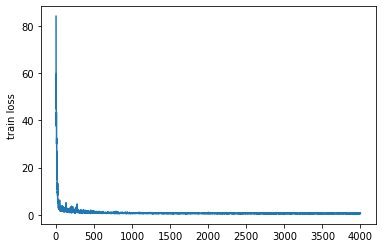

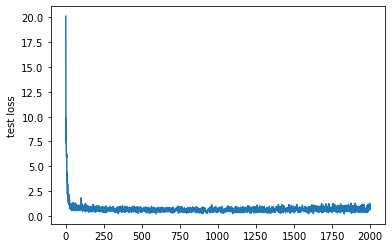

Finished Training


In [6]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(NeuralNet(input_size=99, hidden_size=67, num_classes=2).to(device),2000,15)

In [7]:
device = torch.device(  'cpu')
test(NeuralNet(input_size=99, hidden_size=67, num_classes=2).to(device))

测试集精度为：49%
测试集中不标准动作图片的预测精度为：64%
测试集中标准动作图片的预测精度为：39%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0       16    9
1       23   15


In [23]:
from torchsummary import summary
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast2.pkl')
model.to(device)
summary(model, input_size=(1,99))
print("测试精度如下：")
test(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 67]           6,700
           Dropout-2                [-1, 1, 67]               0
              ReLU-3                [-1, 1, 67]               0
            Linear-4                 [-1, 1, 2]             136
Total params: 6,836
Trainable params: 6,836
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.03
----------------------------------------------------------------
测试精度如下：
测试集精度为：60%
测试集中不标准动作图片的预测精度为：36%
测试集中标准动作图片的预测精度为：76%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0        9   16
1        9   29
